In [1]:
%matplotlib inline
from wrapper import BasicEnvironmentRGB, DomainRandomization, RandomColorReplace
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation, ResizeObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP
from rltesting.utils.torch_utils import EarlyStopping
from fvd_models import Encoder, Decoder, AEVAE
import numpy as np
import torch
import skdim
import os
from tiles import *

np.random.seed(42)
torch.manual_seed(0)
# gym.utils.seeding.np_random(0)

to_numpy = lambda x: x.cpu().detach().numpy() 
framestack = 2
latent_dim = 256
obs_shape = 64
data_steps = 100000
num_epochs = 50
steps_per_epoch = 400
aevae_path = 'aevae_original.pt'

env = gym.make('Acrobot-v1', render_mode="rgb_array")
env = BasicEnvironmentRGB(env)
# env = DomainRandomization(env, {"LINK_LENGTH_1": lambda: np.random.choice([0.5, 1.0, 1.5, 2.0]), "LINK_LENGTH_2": lambda: np.random.choice([0.5, 1.0, 1.5, 2.0])})
env = ResizeObservation(env, (obs_shape, obs_shape))
env = FrameStackObservation(env, stack_size=framestack)
env = TransformObservation(env, lambda obs: np.transpose(obs, (1, 2, 0, 3)), observation_space=gym.spaces.Box(0, 255, (framestack, 3, obs_shape, obs_shape), dtype=np.uint8))
env = TransformObservation(env, lambda obs: np.reshape(obs, (obs_shape, obs_shape, 3 * framestack)), observation_space=gym.spaces.Box(0, 255, (obs_shape, obs_shape, 3 * framestack), dtype=np.uint8))

In [2]:
obs, _ = env.reset()

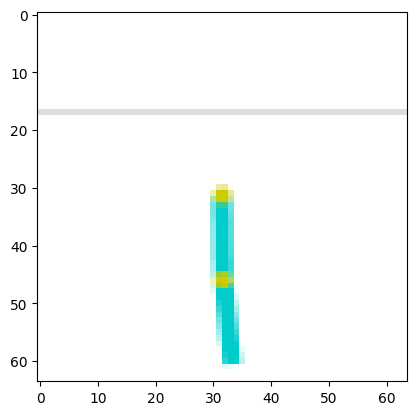

In [3]:
plt.imshow(obs[:, :, :3] / 255)

In [4]:
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=data_steps)
filepath = "testing_buffer.npz"
if os.path.isfile(filepath):
  buffer.load(filepath)
else:
  samples = random_sample_single_env(env, num_steps=data_steps)
  for i in range(data_steps):
      buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())
  buffer.save(filepath=filepath)

In [ ]:
if os.path.isfile('aevae_original.pt'):
    print("Checkpoint found, skipping training.")
else:
    encoder = Encoder(framestack, latent_dim, obs_shape).cuda()
    decoder = Decoder(encoder.conv_dim, framestack, latent_dim).cuda()
    opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 3e-4)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.97)
    early_stop = EarlyStopping(patience=5)

: 

In [ ]:
if os.path.isfile('aevae_original.pt'):
    print("Checkpoint found, skipping training.")
else:
    losses = []
    for i in range(1, num_epochs + 1):
        for _ in range(steps_per_epoch):
            samples = buffer.sample(256)
            obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
            latent = encoder(obs)
            reconstruction = decoder(latent)
            loss = torch.nn.functional.mse_loss(reconstruction, obs)          
            loss.backward()
            opt.step()
            opt.zero_grad()
            losses.append(loss.detach().cpu().numpy())
        scheduler.step()
        if i % 10 == 0:
            print(i * steps_per_epoch)
    plt.plot(losses)

4000
8000
12000


In [ ]:
if os.path.isfile('aevae_original.pt'):
    print("Checkpoint found, skipping training.")
else:
    num_img = 4
    fig, axs = plt.subplots(nrows=num_img, ncols=2, figsize=(4, 2 * num_img))
    for i in range(4):
        axs[i][0].imshow(reconstruction[i].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
        axs[i][0].axis("off")
        axs[i][1].imshow(samples[0][i][:, :, :3])
        axs[i][1].axis("off")
    plt.tight_layout()
    plt.show()
    fig.savefig("direct_dim.png")

Checkpoint found, skipping training.


In [ ]:
if os.path.isfile('aevae_original.pt'):
    print("Checkpoint found, skipping training.")
else:
    latent_ID = []
    image_ID = []

    for _ in range(20):
        samples = buffer.sample(2048)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        latent = encoder(obs)
        unique_latents = np.unique(latent.detach().cpu().numpy(), axis=0)
        unique_obs = np.unique(obs.detach().cpu().numpy(), axis=0).reshape(-1, 3 * framestack*obs_shape*obs_shape)

        latent_ID.append(skdim.id.MLE().fit(unique_latents).dimension_)
        image_ID.append(skdim.id.MLE().fit(unique_obs).dimension_)

    print(f"Latent ID: {np.mean(latent_ID)} +- {np.std(latent_ID)}")
    print(f"Image ID: {np.mean(image_ID)} +- {np.std(image_ID)}")


Checkpoint found, skipping training.


In [ ]:
if os.path.isfile('aevae_original.pt'):
    print("Checkpoint found, skipping training.")
else:
    intrinsic_dim = round(np.mean(latent_ID) * 1.5)
    penalty_coef = 1e-4
    double_autoencoder = AEVAE(encoder, decoder, latent_dim, intrinsic_dim).cuda()
    int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-4)
    int_scheduler = torch.optim.lr_scheduler.ExponentialLR(int_opt, gamma=0.99)
    penalty_anneal = np.linspace(0, 1, num_epochs) ** 0.25 * penalty_coef
    losses = []
    for i in range(1, num_epochs + 1):
        for _ in range(steps_per_epoch):
            samples = buffer.sample(256)
            obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
            loss = double_autoencoder.reconstruction_loss(obs, penalty_anneal[num_epochs-1])
            loss.backward()
            int_opt.step()
            int_opt.zero_grad()
            losses.append(loss.detach().cpu().numpy())
        int_scheduler.step()
        if i % 10 == 0:
            print(i * 2 * steps_per_epoch)
    plt.plot(losses)

Checkpoint found, skipping training.


In [ ]:
if os.path.isfile(aevae_path):
    print("Loading saved AEVAE...")
    ckpt = torch.load(aevae_path, weights_only=False)
    intrinsic_dim = ckpt['intrinsic_dim']
    latent_dim = ckpt['latent_dim']
    encoder = Encoder(framestack, latent_dim, obs_shape).cuda()
    decoder = Decoder(encoder.conv_dim, framestack, latent_dim).cuda()
    double_autoencoder = AEVAE(encoder, decoder, latent_dim, intrinsic_dim).cuda()
    double_autoencoder.load_state_dict(ckpt['weights'])
    print(f"Loaded. Intrinsic dim: {intrinsic_dim}, Latent dim: {latent_dim}")
else:
    print("Saving AEVAE...")
    torch.save({
        'weights': double_autoencoder.state_dict(),
        'intrinsic_dim': intrinsic_dim,
        'latent_dim': latent_dim,
    }, aevae_path)
    print("Saved.")

Loading saved AEVAE...
Loaded. Intrinsic dim: 6, Latent dim: 256


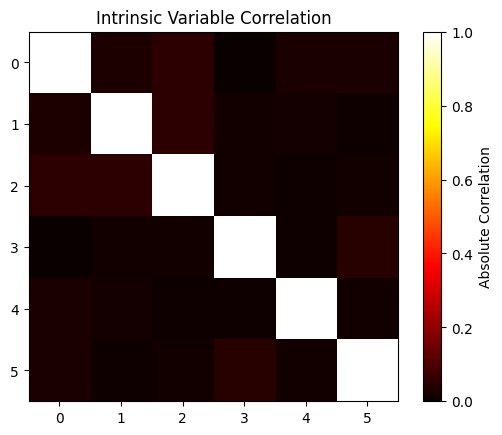

In [ ]:
plt.close('all')
%matplotlib inline
num_samples = 2048
with torch.no_grad():
    samples = buffer.sample(num_samples)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    intrinsic = double_autoencoder.double_encode(obs).cpu().numpy()

corr = np.corrcoef(intrinsic, rowvar=False)
plt.imshow(np.abs(corr), cmap="hot", vmin=0, vmax=1)
plt.colorbar(label="Absolute Correlation")
plt.title("Intrinsic Variable Correlation")
plt.show()

In [ ]:
for name, module in [
    ("Stage 1 Encoder (conv + linear)", double_autoencoder.encoder),
    ("Stage 1 Decoder (linear + conv)", double_autoencoder.decoder),
    ("Intrinsic Encoder (MLP)",         double_autoencoder.intrinsic_encoder),
    ("Intrinsic mu head",               double_autoencoder.intrinsic_mu),
    ("Intrinsic logvar head",           double_autoencoder.intrinsic_logvar),
    ("Intrinsic Decoder (MLP)",         double_autoencoder.intrinsic_decoder),
]:
    n = sum(p.numel() for p in module.parameters())
    print(f"{name:<40s}  {n:>10,}")

total = sum(p.numel() for p in double_autoencoder.parameters())
print(f"{'TOTAL':<40s}  {total:>10,}")

Stage 1 Encoder (conv + linear)              142,552
Stage 1 Decoder (linear + conv)              142,782
Intrinsic Encoder (MLP)                       82,432
Intrinsic mu head                              1,542
Intrinsic logvar head                          1,542
Intrinsic Decoder (MLP)                       33,920
TOTAL                                        404,770


In [ ]:
# ---- Tile coding + Q-learning setup ---- #
num_actions = env.action_space.n

# Collect a large batch to estimate ranges
with torch.no_grad():
    range_samples = buffer.sample(10_000)
    range_obs = (torch.tensor(range_samples[0]).float().transpose(-3, -1) / 255).cuda()
    all_intrinsic = to_numpy(double_autoencoder.double_encode(range_obs))

num_tiles_per_dim = 3
num_tilings = max(16, 4 * intrinsic_dim)  # at least 4x num floats, power of 2
iht_size = (num_tiles_per_dim + 1) ** intrinsic_dim * num_tilings * num_actions
iht_size = max(iht_size, 4096)
iht_size = min(iht_size, 500000)


mins = all_intrinsic.min(axis=0)
maxs = all_intrinsic.max(axis=0)
ranges = maxs - mins
ranges[ranges == 0] = 1.0
buf = 0.02 * ranges
mins = mins - buf
ranges = ranges + 2 * buf
scale = num_tiles_per_dim / ranges

iht = IHT(iht_size)
w = np.zeros(iht_size)
alpha = 0.1 / num_tilings
gamma = 1.0
epsilon_start = 1.0
epsilon_end = 0.05
num_episodes = 500

means = all_intrinsic.mean(axis=0)
stds = all_intrinsic.std(axis=0)
stds[stds == 0] = 1.0

def encode_obs(obs):
    with torch.no_grad():
        t = (torch.tensor(obs).unsqueeze(0).float().transpose(-3, -1) / 255).cuda()
        raw = to_numpy(double_autoencoder.double_encode_deterministic(t)).squeeze()
        return (raw - means) / stds

def get_tiles(state, action):
    scaled = ((state - mins) * scale).tolist()
    return tiles(iht, num_tilings, scaled, ints=[action])

def Q(state, action):
    return np.sum(w[get_tiles(state, action)])

def pick_action(state, eps):
    if np.random.random() < eps:
        return np.random.randint(num_actions)
    qs = [Q(state, a) for a in range(num_actions)]
    return np.argmax(qs)

print(f"Intrinsic dim: {intrinsic_dim}")
print(f"Num tilings: {num_tilings}")
print(f"IHT size: {iht_size}")
print(f"Scale: {scale}")
print(f"Mins: {mins}")
print(f"Maxs: {maxs}")

Intrinsic dim: 6
Num tilings: 24
IHT size: 294912
Scale: [0.39017308 0.5102338  0.4850561  0.42913708 0.41032246 0.4951675 ]
Mins: [-3.8206038 -3.4232748 -3.511345  -3.7281814 -3.940926  -2.972389 ]
Maxs: [3.7204282 2.3433123 2.5545676 3.128154  3.229794  2.9696567]


In [ ]:
# ---- Sanity check tile coding ---- #
print("=== Tile Coding Sanity Check ===\n")

# 1. Same state, same action -> same tiles
test_state = all_intrinsic[0]
t1 = get_tiles(test_state, 0)
t2 = get_tiles(test_state, 0)
print(f"Same (state, action) gives same tiles: {t1 == t2}")

# 2. Same state, different actions -> completely different tiles
tiles_by_action = [get_tiles(test_state, a) for a in range(num_actions)]
for a1 in range(num_actions):
    for a2 in range(a1 + 1, num_actions):
        overlap = set(tiles_by_action[a1]) & set(tiles_by_action[a2])
        print(f"Action {a1} vs {a2} overlap: {len(overlap)} tiles (should be 0)")

# 3. Nearby states -> share some tiles
s1 = all_intrinsic[0]
# find nearest neighbor
dists = np.linalg.norm(all_intrinsic[1:] - s1, axis=1)
s2 = all_intrinsic[1 + np.argmin(dists)]
t_s1 = get_tiles(s1, 0)
t_s2 = get_tiles(s2, 0)
shared = len(set(t_s1) & set(t_s2))
print(f"\nNearest neighbor dist: {np.min(dists):.4f}")
print(f"Shared tiles (nearby): {shared}/{num_tilings}")

# 4. Far apart states -> no shared tiles
s_far = all_intrinsic[np.argmax(dists)]
t_far = get_tiles(s_far, 0)
shared_far = len(set(t_s1) & set(t_far))
print(f"Farthest point dist:   {np.max(dists):.4f}")
print(f"Shared tiles (far):    {shared_far}/{num_tilings} (should be 0)")

# 5. Check scaled range and tile counts
print(f"\n--- Scaling ---")
print(f"Intrinsic dim: {intrinsic_dim}")
print(f"Scaled min:  {((all_intrinsic.min(0) - mins) * scale).round(2)}")
print(f"Scaled max:  {((all_intrinsic.max(0) - mins) * scale).round(2)}")
print(f"Expected ~[0.something, {num_tiles_per_dim} - something] per dim")

# 6. Tile index stats
print(f"\n--- IHT usage ---")
print(f"Tiles per call: {num_tilings}")
print(f"Sample indices:  {t_s1}")
print(f"Index range:     [{min(t_s1)}, {max(t_s1)}]")
print(f"IHT count:       {iht.count()}")
print(f"IHT size:        {iht.size}")
print(f"IHT full:        {iht.fullp()}")

# 7. Q values before training (should all be ~0)
qs = [Q(test_state, a) for a in range(num_actions)]
print(f"\nQ-values before training: {[round(q, 4) for q in qs]} (should be ~0)")

=== Tile Coding Sanity Check ===

Same (state, action) gives same tiles: True
Action 0 vs 1 overlap: 0 tiles (should be 0)
Action 0 vs 2 overlap: 0 tiles (should be 0)
Action 1 vs 2 overlap: 0 tiles (should be 0)

Nearest neighbor dist: 0.5317
Shared tiles (nearby): 14/24
Farthest point dist:   5.7302
Shared tiles (far):    0/24 (should be 0)

--- Scaling ---
Intrinsic dim: 6
Scaled min:  [0.06 0.06 0.06 0.06 0.06 0.06]
Scaled max:  [2.94 2.94 2.94 2.94 2.94 2.94]
Expected ~[0.something, 3 - something] per dim

--- IHT usage ---
Tiles per call: 24
Sample indices:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Index range:     [0, 23]
IHT count:       105
IHT size:        294912
IHT full:        False

Q-values before training: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] (should be ~0)


Episode   50 | Avg Return (last 50):  -498.6 | Epsilon: 0.946 | IHT used: 19293 | Time: 68s
  Timings — Collect: 62.9s | Batch encode: 0.6s | SARSA: 4.9s | Finetune: 0.0s
Episode  100 | Avg Return (last 50):  -495.8 | Epsilon: 0.890 | IHT used: 22506 | Time: 136s
  Timings — Collect: 125.1s | Batch encode: 1.1s | SARSA: 9.8s | Finetune: 0.0s
Episode  150 | Avg Return (last 50):  -497.4 | Epsilon: 0.834 | IHT used: 24352 | Time: 204s
  Timings — Collect: 187.2s | Batch encode: 1.6s | SARSA: 14.8s | Finetune: 0.0s
Episode  200 | Avg Return (last 50):  -497.0 | Epsilon: 0.779 | IHT used: 25618 | Time: 271s
  Timings — Collect: 249.5s | Batch encode: 2.1s | SARSA: 19.8s | Finetune: 0.0s
Episode  250 | Avg Return (last 50):  -500.0 | Epsilon: 0.723 | IHT used: 26396 | Time: 340s
  Timings — Collect: 312.2s | Batch encode: 2.5s | SARSA: 24.9s | Finetune: 0.0s
Episode  300 | Avg Return (last 50):  -491.3 | Epsilon: 0.668 | IHT used: 27443 | Time: 406s
  Timings — Collect: 373.5s | Batch encod

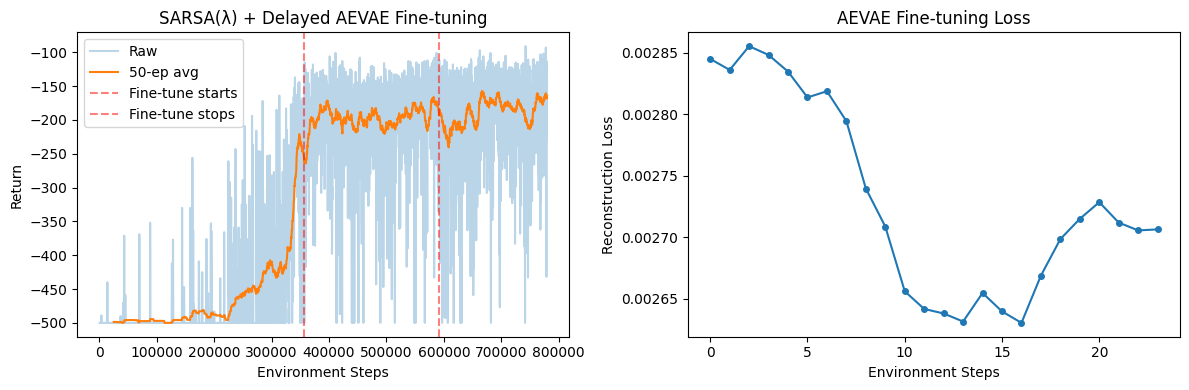


=== Final Timing Breakdown ===
Collect (env + online encode):  2002.2s (92%)
Batch encode:                     17.3s (1%)
SARSA(λ) updates:                139.2s (6%)
Fine-tuning:                      17.8s (1%)
Total accounted:                2176.5s


In [ ]:
# ---- SARSA(λ) with cached encoding + delayed fine-tuning + timings ---- #
import copy
import time

aevae = copy.deepcopy(double_autoencoder)

num_actions = env.action_space.n
num_tiles_per_dim = 3
num_tilings = max(16, 4 * intrinsic_dim)
iht_size = (num_tiles_per_dim + 1) ** intrinsic_dim * num_tilings * num_actions
iht_size = max(iht_size, 4096)

iht = IHT(iht_size)
w = np.zeros(iht_size)
alpha = 0.1 / num_tilings
lam = 0.9
gamma = 1.0
num_episodes = 3000
encode_batch_size = 128

# Fine-tuning setup
finetune_opt = torch.optim.Adam(aevae.parameters(), 1e-4)
finetune_every = 50
finetune_steps = 100
finetune_batch = 128
finetune_after = 800
finetune_until = 2000

with torch.no_grad():
    range_samples = buffer.sample(min(10000, buffer.size))
    range_obs = (torch.tensor(range_samples[0]).float().transpose(-3, -1) / 255).cuda()
    all_intrinsic = to_numpy(aevae.double_encode_deterministic(range_obs))

means = all_intrinsic.mean(axis=0)
stds = all_intrinsic.std(axis=0)
stds[stds == 0] = 1.0
mins = np.full(intrinsic_dim, -3.0)
scale = np.full(intrinsic_dim, num_tiles_per_dim / 6.0)

def batch_encode(obs_array):
    with torch.no_grad():
        results = []
        for i in range(0, len(obs_array), encode_batch_size):
            batch = obs_array[i:i+encode_batch_size]
            t = (torch.tensor(batch).float().transpose(-3, -1) / 255).cuda()
            raw = to_numpy(aevae.double_encode_deterministic(t))
            results.append(raw)
        encoded = np.concatenate(results, axis=0)
        return (encoded - means) / stds

def get_tiles(state, action):
    scaled = ((state - mins) * scale).tolist()
    return tiles(iht, num_tilings, scaled, ints=[action])

def Q(state, action):
    return np.sum(w[get_tiles(state, action)])

def pick_action_from_encoded(state, eps):
    if np.random.random() < eps:
        return np.random.randint(num_actions)
    return max(range(num_actions), key=lambda a: Q(state, a))

def finetune_aevae():
    total_loss = 0
    for _ in range(finetune_steps):
        samples = buffer.sample(finetune_batch)
        obs_t = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        loss = aevae.reconstruction_loss(obs_t)
        loss.backward()
        finetune_opt.step()
        finetune_opt.zero_grad()
        total_loss += loss.item()
    return total_loss / finetune_steps

def recompute_stats():
    with torch.no_grad():
        samples = buffer.sample(min(5000, buffer.size))
        t = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        z = to_numpy(aevae.double_encode_deterministic(t))
    return z.mean(axis=0), np.maximum(z.std(axis=0), 1e-6)

# Timing accumulators
time_collect = 0
time_batch_encode = 0
time_sarsa = 0
time_finetune = 0

returns = []
ft_losses = []
t_start = time.time()
timestep = 0
timesteps = []

for ep in range(num_episodes):
    epsilon = max(0.01, 1.0 - ep / (0.3 * num_episodes))

    # Phase 1: Collect full episode
    t0 = time.time()
    obs, _ = env.reset()
    episode_obs = [obs]
    episode_actions = []
    episode_rewards = []
    episode_dones = []

    with torch.no_grad():
        t = (torch.tensor(obs).unsqueeze(0).float().transpose(-3, -1) / 255).cuda()
        S = to_numpy(aevae.double_encode_deterministic(t)).squeeze()
        S = (S - means) / stds

    A = pick_action_from_encoded(S, epsilon)

    while True:
        obs_next, R, terminated, truncated, _ = env.step(A)
        done = terminated or truncated
        episode_actions.append(A)
        episode_rewards.append(R)
        episode_dones.append(done)

        buffer.add_sample([obs_next, A, R, float(done)])

        if done:
            break

        episode_obs.append(obs_next)
        with torch.no_grad():
            t = (torch.tensor(obs_next).unsqueeze(0).float().transpose(-3, -1) / 255).cuda()
            S = to_numpy(aevae.double_encode_deterministic(t)).squeeze()
            S = (S - means) / stds
        A = pick_action_from_encoded(S, epsilon)

    time_collect += time.time() - t0

    # Phase 2: Batch encode
    t0 = time.time()
    all_states = batch_encode(np.stack(episode_obs))
    time_batch_encode += time.time() - t0

    # Phase 3: SARSA(λ) with sparse traces
    t0 = time.time()
    trace_indices = set()
    e = np.zeros_like(w)
    T = len(episode_actions)

    for t in range(T):
        active = get_tiles(all_states[t], episode_actions[t])
        q_sa = np.sum(w[active])

        if t == T - 1:
            td_error = episode_rewards[t] - q_sa
        else:
            q_next = np.sum(w[get_tiles(all_states[t + 1], episode_actions[t + 1])])
            td_error = episode_rewards[t] + gamma * q_next - q_sa

        # Decay only active traces
        trace_list = list(trace_indices)
        if trace_list:
            e[trace_list] *= gamma * lam
            # Prune negligible traces
            dead = [i for i in trace_list if e[i] < 1e-4]
            for i in dead:
                e[i] = 0.0
                trace_indices.discard(i)

        # Replacing traces
        for i in active:
            e[i] = 1.0
            trace_indices.add(i)

        # Update only traced weights
        if trace_indices:
            trace_list = list(trace_indices)
            w[trace_list] += alpha * td_error * e[trace_list]

    time_sarsa += time.time() - t0

    timestep += T
    timesteps.append(timestep)
    returns.append(sum(episode_rewards))

    # Fine-tuning window
    if (ep + 1) % finetune_every == 0 and finetune_after <= ep < finetune_until:
        t0 = time.time()
        ft_loss = finetune_aevae()
        means, stds = recompute_stats()
        time_finetune += time.time() - t0
        ft_losses.append(ft_loss)

    if (ep + 1) % 50 == 0:
        elapsed = time.time() - t_start
        avg = np.mean(returns[-50:])
        ft_str = f" | FT loss: {ft_losses[-1]:.5f}" if ft_losses else ""
        print(f"Episode {ep+1:4d} | Avg Return (last 50): {avg:7.1f} | "
              f"Epsilon: {epsilon:.3f} | IHT used: {iht.count()} | "
              f"Time: {elapsed:.0f}s{ft_str}")
        print(f"  Timings — Collect: {time_collect:.1f}s | "
              f"Batch encode: {time_batch_encode:.1f}s | "
              f"SARSA: {time_sarsa:.1f}s | "
              f"Finetune: {time_finetune:.1f}s")

# ---- Plot ---- #
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
window = 50

# 1. Raw Returns
axes[0].plot(timesteps, returns, alpha=0.3, label='Raw')

# 2. Smoothed Returns
if len(returns) >= window:
    smoothed = np.convolve(returns, np.ones(window)/window, mode='valid')
    # Slice timesteps to match the length of the smoothed array
    smoothed_timesteps = timesteps[window-1:]
    axes[0].plot(smoothed_timesteps, smoothed, label=f'{window}-ep avg')

# 3. Vertical Lines
# Use the episode index to find the corresponding timestep 
# (subtract 1 because lists are 0-indexed)
ft_start_step = timesteps[finetune_after - 1] if len(timesteps) > finetune_after else None
ft_end_step = timesteps[finetune_until - 1] if len(timesteps) > finetune_until else None

if ft_start_step:
    axes[0].axvline(x=ft_start_step, color='r', linestyle='--', alpha=0.5, label='Fine-tune starts')
if ft_end_step:
    axes[0].axvline(x=ft_end_step, color='r', linestyle='--', alpha=0.5, label='Fine-tune stops')

axes[0].set_xlabel('Environment Steps') # <-- Updated
axes[0].set_ylabel('Return')
axes[0].set_title('SARSA(λ) + Delayed AEVAE Fine-tuning')
axes[0].legend()

# 4. Fine-tuning Loss Plot
if ft_losses:
    # Use the new ft_timesteps list for the x-axis
    axes[1].plot(ft_losses, marker='o', markersize=4) 
    axes[1].set_xlabel('Environment Steps') # <-- Updated
    axes[1].set_ylabel('Reconstruction Loss')
    axes[1].set_title('AEVAE Fine-tuning Loss')

plt.tight_layout()
plt.show()

# Final timing summary
total = time_collect + time_batch_encode + time_sarsa + time_finetune
print(f"\n=== Final Timing Breakdown ===")
print(f"Collect (env + on  line encode): {time_collect:7.1f}s ({100*time_collect/total:.0f}%)")
print(f"Batch encode:                  {time_batch_encode:7.1f}s ({100*time_batch_encode/total:.0f}%)")
print(f"SARSA(λ) updates:              {time_sarsa:7.1f}s ({100*time_sarsa/total:.0f}%)")
print(f"Fine-tuning:                   {time_finetune:7.1f}s ({100*time_finetune/total:.0f}%)")
print(f"Total accounted:               {total:7.1f}s")

Episode   25 | Avg Return (last 25):  -496.4 | Epsilon: 0.880 | IHT used: 46790
IHT full, starting to allow collisions
Episode   50 | Avg Return (last 25):  -488.8 | Epsilon: 0.755 | IHT used: 65536
Episode   75 | Avg Return (last 25):  -475.9 | Epsilon: 0.630 | IHT used: 65536
Episode  100 | Avg Return (last 25):  -456.1 | Epsilon: 0.505 | IHT used: 65536
Episode  125 | Avg Return (last 25):  -439.4 | Epsilon: 0.380 | IHT used: 65536
Episode  150 | Avg Return (last 25):  -429.8 | Epsilon: 0.255 | IHT used: 65536
Episode  175 | Avg Return (last 25):  -436.3 | Epsilon: 0.130 | IHT used: 65536
Episode  200 | Avg Return (last 25):  -396.3 | Epsilon: 0.010 | IHT used: 65536
Episode  225 | Avg Return (last 25):  -400.2 | Epsilon: 0.010 | IHT used: 65536
Episode  250 | Avg Return (last 25):  -378.8 | Epsilon: 0.010 | IHT used: 65536
Episode  275 | Avg Return (last 25):  -331.2 | Epsilon: 0.010 | IHT used: 65536
Episode  300 | Avg Return (last 25):  -372.6 | Epsilon: 0.010 | IHT used: 65536
E

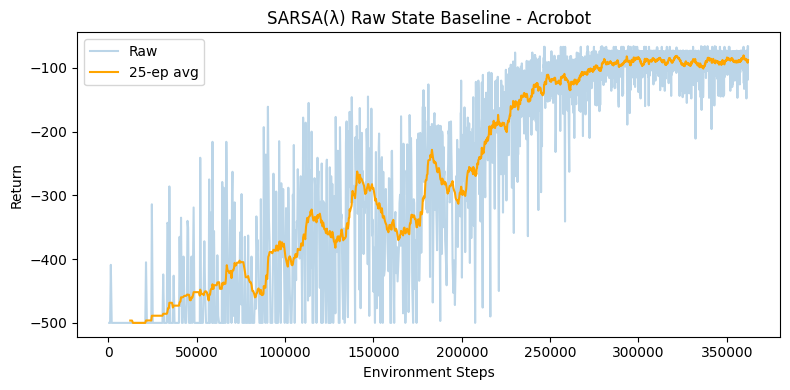

In [ ]:
# ---- SARSA(λ) on raw Acrobot state ---- #
raw_env = gym.make('Acrobot-v1')
raw_num_actions = raw_env.action_space.n

raw_iht = IHT(65536)
raw_num_tilings = 32
raw_w = np.zeros(65536)
raw_alpha = 0.1 / raw_num_tilings
lam = 0.9
gamma = 1.0

raw_scales = np.array([5.0/2, 5.0/2, 5.0/2, 5.0/2, 5.0/25, 5.0/25])
raw_offsets = np.array([1, 1, 1, 1, 12.57, 12.57])

def raw_get_tiles(state, action):
    scaled = ((state + raw_offsets) * raw_scales).tolist()
    return tiles(raw_iht, raw_num_tilings, scaled, ints=[action])

def raw_Q(state, action):
    return np.sum(raw_w[raw_get_tiles(state, action)])

def raw_pick_action(state, eps):
    if np.random.random() < eps:
        return np.random.randint(raw_num_actions)
    return max(range(raw_num_actions), key=lambda a: raw_Q(state, a))

raw_returns = []
timestep = 0
timesteps = []
for ep in range(2000):
    eps = max(0.01, 1.0 - ep / 200)
    obs, _ = raw_env.reset()
    S = np.array(obs)
    A = raw_pick_action(S, eps)
    total_reward = 0
    e = np.zeros_like(raw_w)

    while True:
        obs_next, R, terminated, truncated, _ = raw_env.step(A)
        done = terminated or truncated
        total_reward += R

        active = raw_get_tiles(S, A)
        q_sa = np.sum(raw_w[active])

        if done:
            td_error = R - q_sa
        else:
            S_next = np.array(obs_next)
            A_next = raw_pick_action(S_next, eps)
            q_next = np.sum(raw_w[raw_get_tiles(S_next, A_next)])
            td_error = R + gamma * q_next - q_sa

        # Replacing traces
        e *= gamma * lam
        e[active] = 1.0

        raw_w += raw_alpha * td_error * e
        timestep += 1
        if done:
            break
        S, A = S_next, A_next

    raw_returns.append(total_reward)
    timesteps.append(timestep)
    if (ep + 1) % 25 == 0:
        print(f"Episode {ep+1:4d} | Avg Return (last 25): {np.mean(raw_returns[-25:]):7.1f} | "
              f"Epsilon: {eps:.3f} | IHT used: {raw_iht.count()}")

fig, ax = plt.subplots(figsize=(8, 4))
window = 25

# 1. Plot Raw
ax.plot(timesteps, raw_returns, alpha=0.3, label='Raw')

# 2. Plot Smoothed
if len(raw_returns) >= window:
    smoothed = np.convolve(raw_returns, np.ones(window)/window, mode='valid')
    # Slice timesteps to match the length of the smoothed array
    smoothed_timesteps = timesteps[window-1:]
    ax.plot(smoothed_timesteps, smoothed, label=f'{window}-ep avg', color='orange')

# 3. Set Labels (Fixed 'Episode' to 'Environment Steps')
ax.set_xlabel('Environment Steps') 
ax.set_ylabel('Return')
ax.set_title('SARSA(λ) Raw State Baseline - Acrobot')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ---- SARSA(λ) + RFF on encoder latent (batched) ---- #
import copy
import time

aevae = copy.deepcopy(double_autoencoder)

num_actions = env.action_space.n
num_features = 1024
bandwidth = 1.0
total_features = num_features * num_actions
encode_batch_size = 128

W_rff = np.random.randn(num_features, latent_dim) / bandwidth
b_rff = np.random.uniform(0, 2 * np.pi, num_features)
w = np.zeros(total_features)
alpha = 0.01
lam = 0.9
gamma = 1.0
num_episodes = 2000

with torch.no_grad():
    range_samples = buffer.sample(10000)
    range_obs = (torch.tensor(range_samples[0]).float().transpose(-3, -1) / 255).cuda()
    all_latent = to_numpy(aevae.encoder(range_obs))

means = all_latent.mean(axis=0)
stds = all_latent.std(axis=0)
stds[stds == 0] = 1.0

def batch_encode_latent(obs_array):
    with torch.no_grad():
        results = []
        for i in range(0, len(obs_array), encode_batch_size):
            batch = obs_array[i:i+encode_batch_size]
            t = (torch.tensor(batch).float().transpose(-3, -1) / 255).cuda()
            raw = to_numpy(aevae.encoder(t))
            results.append(raw)
        encoded = np.concatenate(results, axis=0)
        return (encoded - means) / stds

def encode_obs_latent(obs):
    with torch.no_grad():
        t = (torch.tensor(obs).unsqueeze(0).float().transpose(-3, -1) / 255).cuda()
        raw = to_numpy(aevae.encoder(t)).squeeze()
        return (raw - means) / stds

def rff_z(state):
    """Compute RFF features once, reuse for Q and traces."""
    return np.cos(W_rff @ state + b_rff) * np.sqrt(2.0 / num_features)

def Q_all(state):
    z = rff_z(state)
    qs = np.zeros(num_actions)
    for a in range(num_actions):
        s = a * num_features
        qs[a] = w[s:s + num_features] @ z
    return qs

def pick_action(state, eps):
    if np.random.random() < eps:
        return np.random.randint(num_actions)
    return np.argmax(Q_all(state))

time_collect = 0
time_encode = 0
time_sarsa = 0

returns = []
t_start = time.time()

for ep in range(num_episodes):
    epsilon = max(0.01, 1.0 - ep / 600)

    # Phase 1: Collect episode
    t0 = time.time()
    obs, _ = env.reset()
    episode_obs = [obs]
    episode_actions = []
    episode_rewards = []

    S = encode_obs_latent(obs)
    A = pick_action(S, epsilon)

    while True:
        obs_next, R, terminated, truncated, _ = env.step(A)
        done = terminated or truncated
        episode_actions.append(A)
        episode_rewards.append(R)

        if done:
            break

        episode_obs.append(obs_next)
        S = encode_obs_latent(obs_next)
        A = pick_action(S, epsilon)

    time_collect += time.time() - t0

    # Phase 2: Batch encode
    t0 = time.time()
    all_states = batch_encode_latent(np.stack(episode_obs))
    time_encode += time.time() - t0

    # Phase 3: SARSA(λ) with sparse traces
    t0 = time.time()
    trace = np.zeros(total_features)
    trace_nz = set()
    T = len(episode_actions)

    for t in range(T):
        S = all_states[t]
        A = episode_actions[t]
        R = episode_rewards[t]
        z = rff_z(S)

        s = A * num_features
        q_sa = w[s:s + num_features] @ z

        if t == T - 1:
            td_error = R - q_sa
        else:
            S_next = all_states[t + 1]
            A_next = episode_actions[t + 1]
            z_next = rff_z(S_next)
            s_next = A_next * num_features
            q_next = w[s_next:s_next + num_features] @ z_next
            td_error = R + gamma * q_next - q_sa

        # Decay active traces
        if trace_nz:
            trace_list = np.array(list(trace_nz))
            trace[trace_list] *= gamma * lam
            dead = trace_list[np.abs(trace[trace_list]) < 1e-4]
            trace[dead] = 0.0
            trace_nz -= set(dead)

        # Set traces for current features
        active_idx = np.arange(s, s + num_features)
        trace[active_idx] = z
        trace_nz.update(active_idx)

        # Update weights
        if trace_nz:
            trace_list = np.array(list(trace_nz))
            w[trace_list] += alpha * td_error * trace[trace_list]

    time_sarsa += time.time() - t0

    returns.append(sum(episode_rewards))
    if (ep + 1) % 50 == 0:
        elapsed = time.time() - t_start
        avg = np.mean(returns[-50:])
        print(f"Episode {ep+1:4d} | Avg Return (last 50): {avg:7.1f} | "
              f"Epsilon: {epsilon:.3f} | Time: {elapsed:.0f}s")
        print(f"  Collect: {time_collect:.1f}s | Encode: {time_encode:.1f}s | "
              f"SARSA: {time_sarsa:.1f}s")

window = 50
smoothed = np.convolve(returns, np.ones(window)/window, mode='valid')
plt.plot(returns, alpha=0.3, label='Raw')
plt.plot(range(window-1, len(returns)), smoothed, label=f'{window}-ep avg')
plt.xlabel('Episode'); plt.ylabel('Return')
plt.title('SARSA(λ) + RFF on Encoder Latent'); plt.legend(); plt.show()

Episode   50 | Avg Return (last 50):  -500.0 | Epsilon: 0.918 | Time: 71s
  Collect: 62.4s | Encode: 0.5s | SARSA: 8.5s
Episode  100 | Avg Return (last 50):  -500.0 | Epsilon: 0.835 | Time: 143s
  Collect: 124.8s | Encode: 1.0s | SARSA: 17.1s


KeyboardInterrupt: 